## Task 2

len R = 208787
len t = 208787
Ns = 100


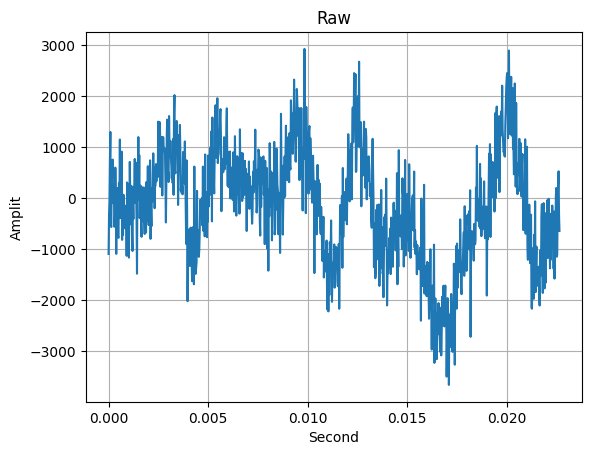

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

fs = 44100
fc = 4000
Ts = 0.0022676
Ns = int(round(fs * Ts))

data = sio.loadmat("Signals_task2/Signal3.mat")
R = np.ravel(data["R"])
t = np.ravel(data["t"])

print("len R =", len(R))
print("len t =", len(t))
print("Ns =", Ns)

plt.plot(t[:1000], R[:1000])
plt.title("Raw")
plt.xlabel("Second")
plt.ylabel("Amplit")
plt.grid()
plt.show()


### Down conversion

Baseband signal length: 208787
[-2178.4524584    +0.j          -556.57479981 +356.67111697j
   -34.99769437  +76.11186716j  -214.41833115-1533.59198541j
 -1693.74562568-1975.27242967j]


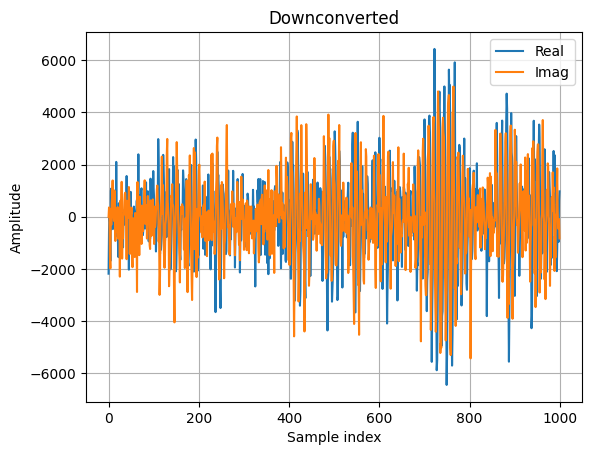

In [7]:
n = np.arange(len(R))

r_bb = 2 * R * np.exp(-1j * 2 * np.pi * fc * n / fs)

print("Baseband signal length:", len(r_bb))
print(r_bb[:5])

num_samples = 1000

plt.plot(np.real(r_bb[:num_samples]), label="Real")
plt.plot(np.imag(r_bb[:num_samples]), label="Imag")
plt.title("Downconverted")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()


## Matched filtering

Length of r_bb: 208787
Length of matched filter output y: 208886


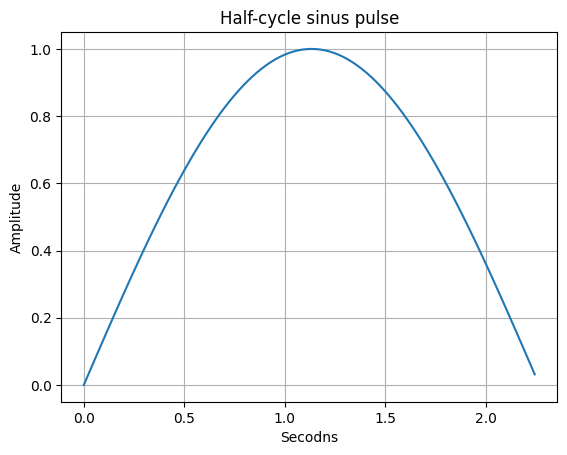

In [8]:
# Half-cycle sinus pulse, same as Task 1
t_pulse = np.arange(Ns) / fs
p = np.sin(np.pi * t_pulse / Ts)

# Matched filter impulse response is time-reversed pulse
h = p[::-1]

# Apply matched filter to complex baseband signal
y = np.convolve(r_bb, h, mode="full")

print("Length of r_bb:", len(r_bb))
print("Length of matched filter output y:", len(y))

plt.plot(t_pulse * 1000, p)
plt.title("Half-cycle sinus pulse")
plt.xlabel("Secodns")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

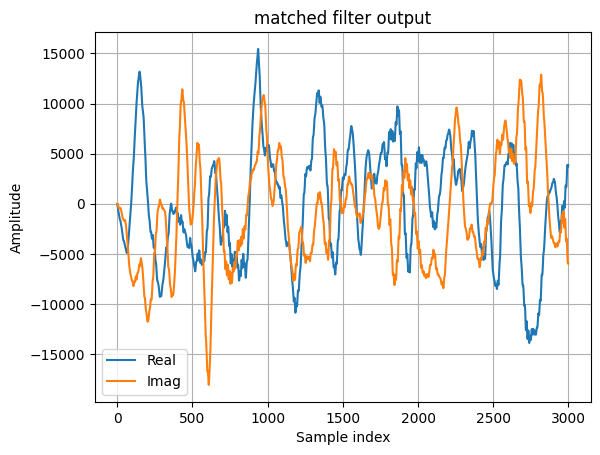

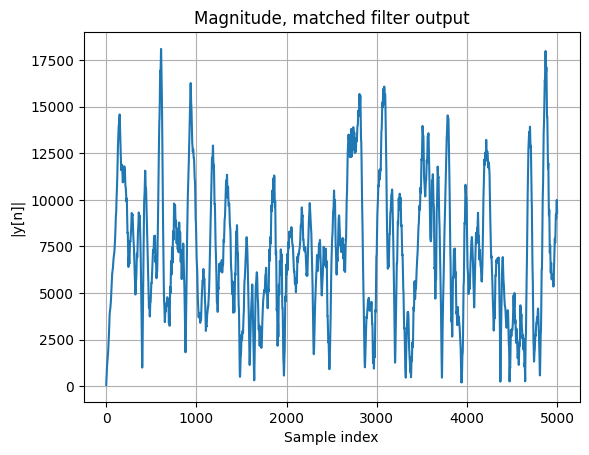

In [11]:
num_samples = 3000

# matched filter output
plt.plot(np.real(y[:num_samples]), label="Real")
plt.plot(np.imag(y[:num_samples]), label="Imag")
plt.title("matched filter output")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

# magnitude
plt.plot(np.abs(y[:5000]))
plt.title("Magnitude, matched filter output")
plt.xlabel("Sample index")
plt.ylabel("|y[n]|")
plt.grid()
plt.show()



## First estimate: strongest symbol samples

Best offset: 38


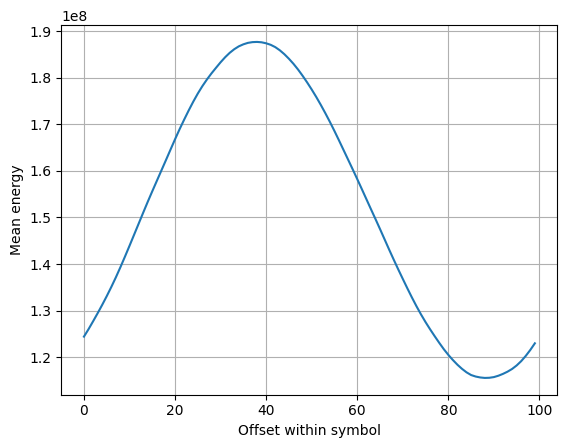

In [13]:
energy_by_offset = []

for offset in range(Ns):
    z_test = y[offset::Ns]
    metric = np.mean(np.abs(z_test)**2)
    energy_by_offset.append(metric)

energy_by_offset = np.array(energy_by_offset)

best_offset = np.argmax(energy_by_offset)

print("Best offset:", best_offset)

plt.plot(energy_by_offset)
plt.xlabel("Offset within symbol")
plt.ylabel("Mean energy")
plt.grid()
plt.show()
